# Capstone project - Air passengers, start to finish

The course pipeline, on this series: explore it, decompose it, set the
benchmark floor, check what the floor leaves on the table, fit a model
through the framework, cross-validate, and read the result against the
floor.

**What is graded is the process, not the number.** A low MASE from one
holdout with no intervals scores worse than an honest analysis that
concludes the benchmark wins.

Full rules and report requirements: `brief.md`. Grading: `rubric.md`. This
notebook is the first deliverable; it should run top to bottom in under ten
minutes on Colab.

In [1]:
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/SDAIAAcademy/international-airpassengers-project.git /content/proj
    %cd /content/proj
    !pip install -q -e .

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from coursekit import plotting as P
from coursekit import scoring

P.use_course_style()

SEASON_LENGTH = 12
H = 12            # forecast horizon for cross-validation
H_REPORT = 24     # forecast horizon for the report

/content/proj
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.0 MB/s eta 0:00:00
  Building editable for international-airpassengers-project (pyproject.toml) ... done


/content/proj/coursekit/plotting.py:599: SyntaxWarning: invalid escape sequence '\h'
  :math:`\hat{F}` whose characteristics do not change over time -- so that a
/content/proj/coursekit/plotting.py:676: SyntaxWarning: invalid escape sequence '\h'
  """Draw the h-step errors :math:`e_{t+h|t} = y_{t+h} - \hat{y}_{t+h|t}`.


---
# 0. The data

Monthly international air passenger numbers, 1949-01 to 1960-12: 144
observations, no gaps. The Box & Jenkins classic (1970) — twelve years of
growth, and a year that does not repeat the same way twice.

Fetched from statsmodels' R-datasets on first run; no download step.

In [2]:
from statsmodels.datasets import get_rdataset

raw = get_rdataset("AirPassengers").data
t = raw["time"].astype(float).to_numpy()
years = np.floor(t).astype(int)
months = np.clip(np.round((t - years) * 12).astype(int) + 1, 1, 12)
df = pd.DataFrame({
    "unique_id": "Air passengers (Box & Jenkins)",
    "ds": pd.to_datetime(pd.Series(years).astype(str) + "-" +
                         pd.Series(months).astype(str).str.zfill(2) + "-01"),
    "y": raw["value"].astype(float),
}).sort_values("ds").reset_index(drop=True)
df.head()

,unique_id,ds,y
0,Air passengers (Box & Jenkins),1949-01-01,112.0
1,Air passengers (Box & Jenkins),1949-02-01,118.0
2,Air passengers (Box & Jenkins),1949-03-01,132.0
3,Air passengers (Box & Jenkins),1949-04-01,129.0
4,Air passengers (Box & Jenkins),1949-05-01,121.0


In [3]:
# TODO: confirm the calendar. How many months, what range, any gaps?
#       (Same three checks you ran on the spine on Day 1.)
n_obs = len(df)
range_ = (df["ds"].min(), df["ds"].max())
expected_months = pd.date_range(
    start=df["ds"].min(),
    end=df["ds"].max(),
    freq="MS"
)
n_gaps = len(expected_months.difference(df["ds"]))
print(f"{n_obs} months, {range_[0].date()} to {range_[1].date()}, {n_gaps} gaps")

144 months, 1949-01-01 to 1960-12-01, 0 gaps


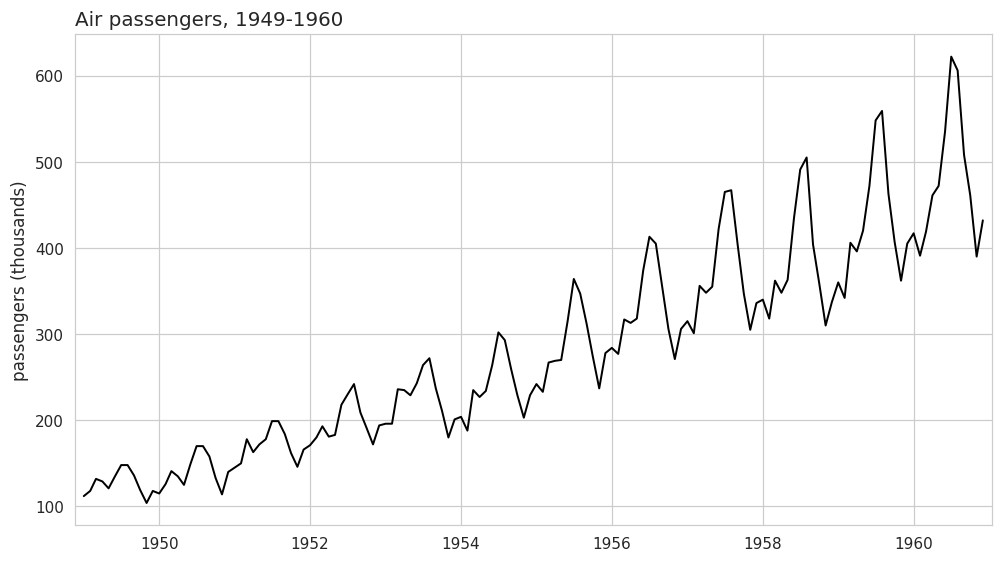

In [4]:
P.plot_series(df, title="Air passengers, 1949-1960",
              ylabel="passengers (thousands)", xlabel="")
plt.show()

**First read.** Before any model, write two sentences that describe this
series in plain language - the kind a non-forecaster could repeat. (Trend?
Seasonality? What happens to the swings as the level grows? Cycle?) These two
sentences belong at the top of your report.

It is evident that the number of passengers is increasing over the years; in other words, there is a general upward trend from 1949 to 1960. There is also a recurring annual seasonal pattern, and as the number of passengers has grown, the ups and downs have become larger.

---
# 1. Exploration and shape

The Day 1 toolkit, in order. Every chart should carry its claim: a title that
says what it shows, not just "series".

**1.1 Decompose.** STL, additive, period 12. Read all three panels: which
component does the work, and what does the remainder look like?

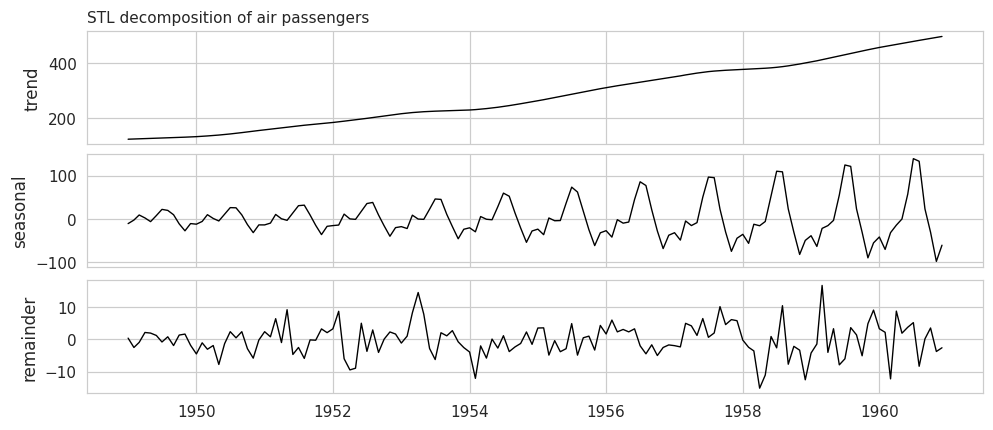

In [5]:
# TODO: STL decomposition (statsmodels), additive, period=12.
#       Then plot the components with P.decomposition_plot.
from statsmodels.tsa.seasonal import STL

stl = STL(df["y"], period=12)
stl_result = stl.fit()

dcmp = pd.DataFrame({
    "ds": df["ds"],
    "trend": stl_result.trend,
    "seasonal": stl_result.seasonal,
    "remainder": stl_result.resid
})

P.decomposition_plot(
    dcmp,
    cols=["trend", "seasonal", "remainder"],
    title="STL decomposition of air passengers",
    x="ds"
)

plt.show()

The analysis indicates that the general trend is the primary component explaining the continuous increase in the number of passengers over time. A clear seasonal pattern also emerges—recurring annually and intensifying as passenger numbers rise—while the residuals remain relatively small and generally center around zero.

**1.2 Trend and seasonal strength.** The two numbers from Day 1, computed
the same way (textbook formulas on the STL components). State what they
imply for model choice.

In [6]:
# TODO: trend_strength and seasonal_strength from the STL components.
remainder = dcmp["remainder"]
trend = dcmp["trend"]
seasonal = dcmp["seasonal"]

trend_strength = max(
    0,
    1 - np.var(remainder) / np.var(trend + remainder)
)

seasonal_strength = max(
    0,
    1 - np.var(remainder) / np.var(seasonal + remainder)
)

print(f"trend strength: {trend_strength:.2f}")
print(f"seasonal strength: {seasonal_strength:.2f}")

trend strength: 1.00
seasonal strength: 0.99


Values ​​close to 1 indicate that the series exhibits a very strong trend and very strong annual seasonality. Therefore, it is appropriate to test a model that accounts for both trend and seasonality—such as ETS or Holt-Winters—and then compare its performance against the Seasonal Naive method benchmark using cross-validation before selecting the final model.

**1.3 Autocorrelation.** The ACF of the raw series. What is at lag 12?
At 24? What does that tell you before you fit anything?

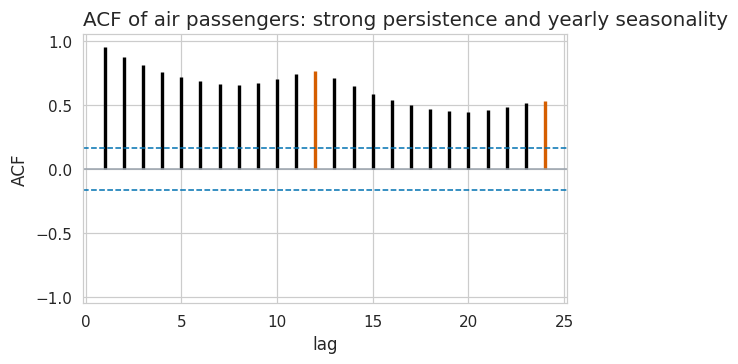

In [7]:
# TODO: ACF plot of df["y"] (P.acf_plot), 24 lags.
P.acf_plot(
    df["y"],
    nlags=24,
    title="ACF of air passengers: strong persistence and yearly seasonality",
    highlight_every=12
)

plt.show()

Autocorrelation remains high across multiple lags, with clear correlations observed at lag 12 and lag 24. The spike at lag 12 indicates a strong correlation between the number of passengers in a given month and the same month of the previous year, confirming the presence of annual seasonality. The persistence of this correlation at lag 24 suggests that the pattern remains evident even after two years. Consequently, prior to model construction, we anticipate the need for a model—or a benchmark—capable of accounting for both seasonality and trend.

---
# 2. The floor

The seasonal naive is the first model you fit on any series - not as a
formality, as the thing everything else has to beat. Fit it, check what it
leaves on the table, and give it an honest interval.

In [21]:
from statsforecast.models import Naive

benchmark_sf = StatsForecast(
    models=[Naive()],
    freq="MS",
    n_jobs=1
)

benchmark_fc = benchmark_sf.forecast(
    df=df,
    h=H_REPORT,
    level=scoring.LEVELS
)

benchmark_fc.head()

,unique_id,ds,Naive,Naive-lo-20,Naive-lo-40,Naive-lo-60,Naive-lo-80,Naive-lo-95,Naive-hi-20,Naive-hi-40,Naive-hi-60,Naive-hi-80,Naive-hi-95
0,Air passengers (Box & Jenkins),1961-01-01,432.0,423.459566,414.322245,403.628605,388.798374,365.928814,440.540434,449.677755,460.371395,475.201626,498.071186
1,Air passengers (Box & Jenkins),1961-02-01,432.0,419.922002,406.999879,391.876788,370.903674,338.561233,444.077998,457.000121,472.123212,493.096326,525.438767
2,Air passengers (Box & Jenkins),1961-03-01,432.0,417.207534,401.381230,382.859302,357.172589,317.561350,446.792466,462.618770,481.140698,506.827411,546.438650
3,Air passengers (Box & Jenkins),1961-04-01,432.0,414.919132,396.644490,375.257210,345.596748,299.857629,449.080868,467.355510,488.742790,518.403252,564.142371
4,Air passengers (Box & Jenkins),1961-05-01,432.0,412.903009,392.471338,368.559632,335.398227,284.260338,451.096991,471.528662,495.440368,528.601773,579.739662


In [8]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive

floor_sf = StatsForecast(models=[SeasonalNaive(season_length=SEASON_LENGTH)],
                         freq="MS", n_jobs=1)
floor_fc = floor_sf.forecast(df=df, h=H_REPORT, level=scoring.LEVELS)
floor_fc.head()

,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1961-01-01,417.0,407.799511,397.956005,386.435898,370.4595,345.822448,426.200489,436.043995,447.564102,463.5405,488.177552
1,Air passengers (Box & Jenkins),1961-02-01,391.0,381.799511,371.956005,360.435898,344.4595,319.822448,400.200489,410.043995,421.564102,437.5405,462.177552
2,Air passengers (Box & Jenkins),1961-03-01,419.0,409.799511,399.956005,388.435898,372.4595,347.822448,428.200489,438.043995,449.564102,465.5405,490.177552
3,Air passengers (Box & Jenkins),1961-04-01,461.0,451.799511,441.956005,430.435898,414.4595,389.822448,470.200489,480.043995,491.564102,507.5405,532.177552
4,Air passengers (Box & Jenkins),1961-05-01,472.0,462.799511,452.956005,441.435898,425.4595,400.822448,481.200489,491.043995,502.564102,518.5405,543.177552


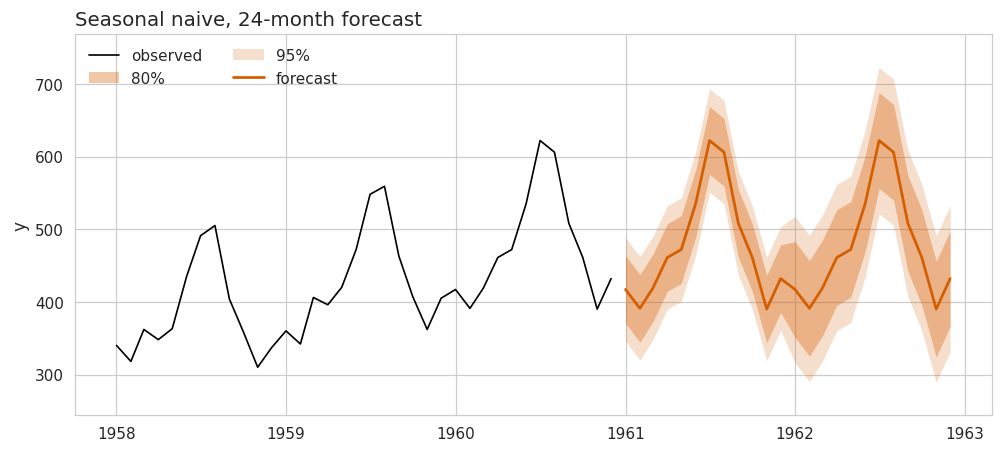

In [9]:
P.fan_chart(df, floor_fc.rename(columns={
            "SeasonalNaive": "mean",
            "SeasonalNaive-lo-20": "lo-20",
            "SeasonalNaive-lo-40": "lo-40",
            "SeasonalNaive-lo-60": "lo-60",
            "SeasonalNaive-lo-80": "lo-80",
            "SeasonalNaive-lo-95": "lo-95",
            "SeasonalNaive-hi-20": "hi-20",
            "SeasonalNaive-hi-40": "hi-40",
            "SeasonalNaive-hi-60": "hi-60",
            "SeasonalNaive-hi-80": "hi-80",
            "SeasonalNaive-hi-95": "hi-95",
            "ds": "ds"}),
            title="Seasonal naive, 24-month forecast",
            history_tail=36, levels=(80, 95))
plt.show()

**2.1 What is left on the table.** The floor's in-sample residuals are
``y_t - y_{t-12}`` over the series. Ljung-Box at 12 and 24 lags. If it is not
white noise, what structure is it, and which kind of model eats that
structure?

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# TODO: residuals, Ljung-Box at lags [12, 24], record the p-values.
resid_floor = df["y"].diff(SEASON_LENGTH).dropna()

lb_floor = acorr_ljungbox(
    resid_floor,
    lags=[12, 24],
    return_df=True
)

print(lb_floor)

       lb_stat     lb_pvalue
12  234.493675  2.319678e-43
24  275.036389  1.711303e-44


The p-values ​​at lags 12 and 24 are very small, indicating that the residuals are not white noise. This demonstrates that the Seasonal Naive model leaves some temporal structure unexplained. A more flexible model, such as ETS, could potentially capture some of this remaining structure, but this must be verified using rolling-origin cross-validation.

---
# 3. Your model: the framework

AutoGluon fits a zoo of models behind one call - every model in the zoo
below is a model you have met in this course. The install is large, so this
runs on Colab.

> Every cell in this section is **skip-guarded**: without `autogluon`
> installed it prints why and moves on, so the rest of the notebook still
> runs.

In [13]:
import importlib.util

HAS_AG = importlib.util.find_spec("autogluon") is not None
if not HAS_AG:
    print("autogluon is not installed. On Colab, run this and re-run the cell:")
    print("    !pip install -q 'autogluon.timeseries'")
    print("\n(Takes a few minutes. A runtime reset wipes it.)")
else:
    print("autogluon is available")

autogluon is available


In [12]:
!pip install -q 'autogluon.timeseries'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 631.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.4/274.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.7/90.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.4/248.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 514.8/514.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.4/285.4 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.0/864.0 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

**3.1 The data conversion stays visible.** AutoGluon has its own
frame, its own column names, its own fit loop and its own leaderboard.
Writing it out by hand once is the point - the gap between two APIs doing
the same job is the thing to notice.

| | this course | AutoGluon |
|---|---|---|
| id column | `unique_id` | `item_id` |
| time column | `ds` | `timestamp` |
| value column | `y` | `target` (nameable) |
| frame | `pd.DataFrame` | `TimeSeriesDataFrame` |

In [14]:
if HAS_AG:
    from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

    # Long format to AutoGluon's long format: the same three columns, renamed.
    ag_long = df.rename(columns={"unique_id": "item_id", "ds": "timestamp"})
    tsdf = TimeSeriesDataFrame.from_data_frame(
        ag_long, id_column="item_id", timestamp_column="timestamp")

    # One 12-month holdout, cut the way AutoGluon expects.
    ag_train = tsdf.slice_by_timestep(None, -12)

    print(tsdf.head(3))
    print(f"\nfull: {len(tsdf)} rows   train: {len(ag_train)} rows")

                                               y
item_id                        timestamp        
Air passengers (Box & Jenkins) 1949-01-01  112.0
                               1949-02-01  118.0
                               1949-03-01  132.0

full: 144 rows   train: 132 rows


In [15]:
if HAS_AG:
    # Local models only - the same zoo this course taught, nothing neural.
    ZOO = {"Naive": {}, "SeasonalNaive": {}, "AutoETS": {},
           "AutoARIMA": {}, "Theta": {}}

    predictor = TimeSeriesPredictor(
        prediction_length=12, target="y", eval_metric="MASE",
        freq="MS", verbosity=1)
    predictor.fit(ag_train, hyperparameters=ZOO, time_limit=120)

In [16]:
# TODO: display the leaderboard on the held-out months (predictor.leaderboard(tsdf)).
#       Read it: what is the SIGN of score_val, which models did it fit, and
#       how many windows did it score them on?
leaderboard = predictor.leaderboard(tsdf)
leaderboard

,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,AutoARIMA,-0.608073,-1.575987,0.302435,0.079196,0.009234,5
1,WeightedEnsemble,-0.929514,-1.535792,0.479402,0.175576,0.181727,6
2,AutoETS,-1.169539,-1.554323,0.175247,0.095092,0.009733,4
3,Theta,-1.570881,-1.656513,0.036843,0.014855,0.011431,3
4,SeasonalNaive,-1.570881,-1.656513,0.027689,0.007090,0.011586,2
5,Naive,-2.495895,-3.196371,0.026772,0.005651,0.016912,1


**3.2 Read what it handed back.** What is the *sign* of `score_val`, and
what does the answer to "how many windows" mean for how much you should
trust this ranking? It decides what the next section does with this table.
And: does the shortlist agree with the shape you read in section 1?

The `score_val` values ​​are negative because AutoGluon presents MASE as a score where higher values ​​are better; thus, less negative values ​​indicate better performance. Although AutoARIMA was the best single model on the holdout months according to `score_test`, this result is based on a single window and is therefore insufficient for selecting the final model. Furthermore, the result for Theta does not reflect its true performance in this run, as it failed and defaulted to SeasonalNaive. Consequently, we need to apply rolling-origin cross-validation across eight windows to determine whether this ranking is consistent.

---
# 4. The harness

The framework's ranking came from one internal split. One holdout is not a
ranking. So the shortlist goes through the rolling-origin harness: eight
origins, twelve months each, the whole distribution scored - and the floor
stays in the table.

In [17]:
sf_cv = StatsForecast(
    models=[SeasonalNaive(season_length=SEASON_LENGTH)],
    freq="MS", n_jobs=1)
cv = sf_cv.cross_validation(df=df, h=H, step_size=H, n_windows=8,
                            level=scoring.LEVELS)
cv.head()

,unique_id,ds,cutoff,y,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1953-01-01,1952-12-01,196.0,171.0,164.48674,157.518271,149.362895,138.052796,120.6116,177.51326,184.481729,192.637105,203.947204,221.3884
1,Air passengers (Box & Jenkins),1953-02-01,1952-12-01,196.0,180.0,173.48674,166.518271,158.362895,147.052796,129.6116,186.51326,193.481729,201.637105,212.947204,230.3884
2,Air passengers (Box & Jenkins),1953-03-01,1952-12-01,236.0,193.0,186.48674,179.518271,171.362895,160.052796,142.6116,199.51326,206.481729,214.637105,225.947204,243.3884
3,Air passengers (Box & Jenkins),1953-04-01,1952-12-01,235.0,181.0,174.48674,167.518271,159.362895,148.052796,130.6116,187.51326,194.481729,202.637105,213.947204,231.3884
4,Air passengers (Box & Jenkins),1953-05-01,1952-12-01,229.0,183.0,176.48674,169.518271,161.362895,150.052796,132.6116,189.51326,196.481729,204.637105,215.947204,233.3884


In [22]:
autoarima_errors = (
    mycv["y"] - mycv["AutoARIMA"]
).dropna()

lb_autoarima = acorr_ljungbox(
    autoarima_errors,
    lags=[12, 24],
    return_df=True
)

print(lb_autoarima)

       lb_stat     lb_pvalue
12  149.984055  5.712247e-26
24  240.353032  1.337087e-37


In [23]:
floor_width_80 = (
    cv["SeasonalNaive-hi-80"] - cv["SeasonalNaive-lo-80"]
).mean()

autoarima_width_80 = (
    mycv["AutoARIMA-hi-80"] - mycv["AutoARIMA-lo-80"]
).mean()

print(f"SeasonalNaive mean 80% interval width: {floor_width_80:.2f}")
print(f"AutoARIMA mean 80% interval width: {autoarima_width_80:.2f}")

SeasonalNaive mean 80% interval width: 77.76
AutoARIMA mean 80% interval width: 44.08


In [18]:
print([name for name in dir(scoring) if not name.startswith("_")])

['LEVELS', 'QCOLS', 'QUANTILES', 'annotations', 'coverage', 'mase', 'np', 'pd', 'qcols', 'rmsse', 'scaled_crps', 'score_cv']


In [19]:
import inspect

print(inspect.signature(scoring.score_cv))
print(scoring.score_cv.__doc__)

(cv: 'pd.DataFrame', model: 'str', train_df: 'pd.DataFrame', seasonality: 'int' = 12, level: 'int' = 80, cutoff_col: 'str' = 'cutoff') -> 'dict'
Score one model over a rolling-origin cross-validation frame.

``cv`` is what ``StatsForecast.cross_validation(..., level=LEVELS)``
returns; ``train_df`` is the full series the folds were cut from. Returns
the keyword arguments ``coursekit.leaderboard.record`` takes, plus the best
and worst fold MASE, because a mean with no spread is the thing Day 2
spends an hour arguing against.



In [20]:
# TODO: pick the model your leaderboard shortlists (the statsforecast twin
#       of the winner: AutoTheta / AutoETS / AutoARIMA ...), cross-validate
#       it over the SAME folds, and put BOTH models in one table - one row
#       per model: mase, rmsse, crps, coverage_80 (plus the min/max MASE).
from statsforecast.models import AutoARIMA

MY_MODEL = AutoARIMA(season_length=SEASON_LENGTH)
MY_NAME = "AutoARIMA"

mysf = StatsForecast(
    models=[MY_MODEL],
    freq="MS",
    n_jobs=1
)

mycv = mysf.cross_validation(
    df=df,
    h=H,
    step_size=H,
    n_windows=8,
    level=scoring.LEVELS
)

floor_scores = scoring.score_cv(
    cv=cv,
    model="SeasonalNaive",
    train_df=df,
    seasonality=SEASON_LENGTH,
    level=80
)

model_scores = scoring.score_cv(
    cv=mycv,
    model=MY_NAME,
    train_df=df,
    seasonality=SEASON_LENGTH,
    level=80
)

RESULTS = pd.DataFrame(
    [floor_scores, model_scores],
    index=["SeasonalNaive", MY_NAME]
)

RESULTS

,mase,rmsse,crps,coverage_80,mase_min,mase_max
SeasonalNaive,1.313310,1.245572,0.061603,0.510417,0.411584,1.958726
AutoARIMA,0.647227,0.683266,0.033870,0.697917,0.330149,1.593848


**4.1 Read the table.** Does the harness confirm the leaderboard's
shortlist, or does it move it? For each model: where does it beat the
floor, where does it lose, and on which of the three metrics? A model that
wins the point forecast and loses the distribution is a real result -
report both halves. And what does each model's 80% coverage say about its
band?

Rolling-origin cross-validation confirms the choice of AutoARIMA; it outperformed the Seasonal Naive model in terms of MASE, RMSSE, and CRPS. Furthermore, AutoARIMA achieved an 80% prediction interval coverage of approximately 69.8%, compared to 51.0% for the Seasonal Naive model; while AutoARIMA’s intervals are more reliable, the coverage remains below the nominal 80% level, indicating that the prediction intervals are still too narrow. Overall, AutoARIMA surpasses the benchmark in point forecast accuracy and distributional quality, despite the persistent issue of undercoverage.

---
# 5. The report

The notebook is evidence; the report is the claim. Two to three pages, for a
manager who will not open the notebook:

- **The recommendation.** Which model you would ship, in one sentence, and
  the one number that earns it.
- **The intervals.** How wide, what they covered, and whether the band is
  honest. Coverage is the check a band cannot do alone.
- **The residuals.** What the floor - and your model - missed. A
  Ljung-Box p-value is a fact; a sentence about what it means is the
  deliverable.
- **One change.** A specific next step - data, driver, frequency, horizon -
  and what you expect it to do.

Rules: every number in the report comes out of this notebook; no number
that could not have come out of the harness counts; no leakage - a fold's
fit and its denominator use only data that fold was allowed to see.

**Optional, for extra credit.** The series is a total across origins, so a
driver is a modelling choice, not a lookup: pick a region and pull its
monthly mean temperature from a public weather archive (for example
Open-Meteo's historical API - free, no key), cache it next to the CSV, and
regress on it. That is dynamic regression - and the cross-validation
discipline still applies to the regression's residuals.